In [1]:
import torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import RichProgressBar, Timer, LearningRateFinder
import omegaconf


# Add the prime_torch file to the system path so we can import it
import sys
sys.path.append("/glade/u/home/cobrien/prime/prime_lib/primesw")
from data import SWDataset, SWDataModule
from prime_torch import crps, SWRegressor

In [3]:
torch.set_float32_matmul_precision('medium')

config = '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet.yaml'
cfg = omegaconf.OmegaConf.load(
    config
)

# Running .setup() with this DataModule will take like an hour. Find a way to cache this dataloader
datamodule = SWDataModule(
    target_features = cfg.data.target_features,
    input_features = cfg.data.input_features,
    position_features = cfg.data.position_features,
    interp_flags = cfg.data.interp_flags,
    region = cfg.data.region,
    cuts = cfg.data.cuts,
    cadence = cfg.data.cadence,
    interpolate = cfg.data.interpolate,
    window = cfg.data.window,
    stride = cfg.data.stride,
    interp_frac = cfg.data.interp_frac,
    trn_bounds = cfg.data.trn_bounds,
    val_bounds = cfg.data.val_bounds,
    tst_bounds = cfg.data.tst_bounds,
    batch_size = cfg.opt.batch_size,
    num_workers = cfg.opt.num_workers,
    datastore = cfg.data.datastore,
    in_key = cfg.data.in_key,
    tar_key = cfg.data.tar_key,
    scaler_type = cfg.data.scaler_type,
)

model = SWRegressor.load_from_checkpoint(
    "/glade/u/home/cobrien/data/prime/tensorboard_logs/pstesting/version_21/checkpoints/epoch=299-step=10800.ckpt"
)

/glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [4]:
# Load the data
wind_data = pd.read_hdf('/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5', key = 'wind_full', mode = 'r')
# print(wind_data.std())
themis_data = pd.read_csv('/glade/u/home/cobrien/data/themis/combined_loc_themis_cleaned.csv', index_col=None)
themis_data = themis_data.drop(index = [0,1])
themis_data['datetime'] = pd.to_datetime(themis_data['datetime'], utc = True)

In [5]:
# Make the position inputs and cut the input wind data to just the interval covered by the themis data
wind_data = wind_data.loc[
    (wind_data['Epoch'] <= themis_data['datetime'].max())&
    (wind_data['Epoch'] >= themis_data['datetime'].min() - pd.Timedelta(seconds = (model.stride + model.window) * 100)),
    :
]
positions = pd.DataFrame(wind_data['Epoch'], columns = ['Epoch'])
positions['Rx_int'] = -20 # np.interp(positions['Epoch'], themis_data['datetime'], themis_data['X_GSM'])
positions['Ry_int'] = 0 # np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Y_GSM'])
positions['Rz_int'] = 0 # np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Z_GSM'])

In [6]:
# model.in_norm = datamodule.input_normalizations
# model.pos_norm = datamodule.position_normalizations
prime_data = model.predict(wind_data, positions)

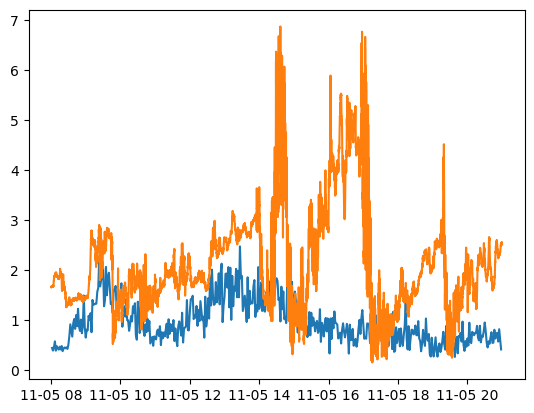

In [7]:
import matplotlib.pyplot as plt

plt.plot(prime_data['Epoch'], prime_data['N'])
plt.plot(themis_data['datetime'], themis_data['density'])

In [8]:
model.tar_norm

# Version 7
# {'N': (0.4513633866274092, 0.8961303138350295),
#  'temp': (4341.372569394547, 2439.7238682921293)}
# {'Ni': (7.575942, 1635.399),
#  'Vi_xgse': (-421.1689, 104.84078),
#  'Vi_ygse': (-1.1496662, 61.705624),
#  'Vi_zgse': (-2.79055, 45.4899),
#  'Vth': (36.56218, 18.75177),
#  'R_xgse': (180.33188, 90.915596),
#  'R_ygse': (-1.7973562, 80.85694),
#  'R_zgse': (1.9249461, 12.063982),
#  'B_xgsm': (-0.061672468, 5.62544),
#  'B_ygsm': (0.16372976, 6.1474695),
#  'B_zgsm': (0.00834217, 6.5854907),
#  'SME': (223.32116705400375, 225.9355978286592),
#  'SMR': (-7.750147104476214, 18.173108763733058),
#  'tilt': (0.20978173066208744, 17.785085176785703)}

# Version 12
# {'N': (0.4513633866274092, 0.8961303138350295),
#  'temp': (4341.372569394547, 2439.7238682921293)}
# {'Ni': (7.575942, 1635.399),
#  'Vi_xgse': (-421.1689, 104.84078),
#  'Vi_ygse': (-1.1496662, 61.705624),
#  'Vi_zgse': (-2.79055, 45.4899),
#  'Vth': (36.56218, 18.75177),
#  'R_xgse': (180.33188, 90.915596),
#  'R_ygse': (-1.7973562, 80.85694),
#  'R_zgse': (1.9249461, 12.063982),
#  'B_xgsm': (-0.061672468, 5.62544),
#  'B_ygsm': (0.16372976, 6.1474695),
#  'B_zgsm': (0.00834217, 6.5854907),
#  'SME': (223.32116705400375, 225.9355978286592),
#  'SMR': (-7.750147104476214, 18.173108763733058),
#  'tilt': (0.20978173066208744, 17.785085176785703)}

{'N': (0.281125, 0.35383333333333333), 'temp': (4064.375, 3172.21875)}

In [11]:
# Synthetic SW 2D maps
# Init synthetic solar wind datastructures
synth_data = pd.DataFrame(np.zeros((model.window+1, len(datamodule.input_features))), columns = datamodule.input_features)
# synth_data['Epoch'] = pd.to_datetime('2000-01-01 00:00:00+0000') # This time is unused, but model.predict() throws a warning when input data has no Epoch
synth_pos = pd.DataFrame(np.zeros((model.window+1, 3)), columns = datamodule.position_features)

synth_overrides = {
    'Ni' : 3,
    'Vi_xgse' : -380,
    'Vi_ygse' : - 30,
    'Vi_zgse' : -2.8,
    'Vth' : 36,
    'R_xgse' : 197.8,
    'R_ygse' : -0.03,
    'R_zgse' : -10.7,
    'B_xgsm' : -0.06,
    'B_ygsm' : 0.16,
    'B_zgsm' : -5,
    'SME' : 200,
    'SMR' : 0,
    'tilt' : 15,
}

# Override the prior values (currently empty) with new synthetic conditions
for key in synth_overrides.keys():
    synth_data[key] = synth_overrides[key]

In [12]:
# Define the grid extent
x_extent = [-30, -5]
y_extent = [-15, 15]
gridsize = 0.5

# Initialize the grid
x_arr = np.arange(x_extent[0], x_extent[1], gridsize)
y_arr = np.arange(x_extent[0], x_extent[1], gridsize)
output_grid = np.zeros((1, len(x_arr), len(y_arr), len(datamodule.target_features)*2))

for i, x in enumerate(x_arr):
    for j, y in enumerate(y_arr):
        synth_pos[datamodule.position_features[0]] = x
        synth_pos[datamodule.position_features[0]] = y
        output_grid[0, i, j, :] = model.predict(synth_data, synth_pos)

/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:182: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:182: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:182: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:182: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')


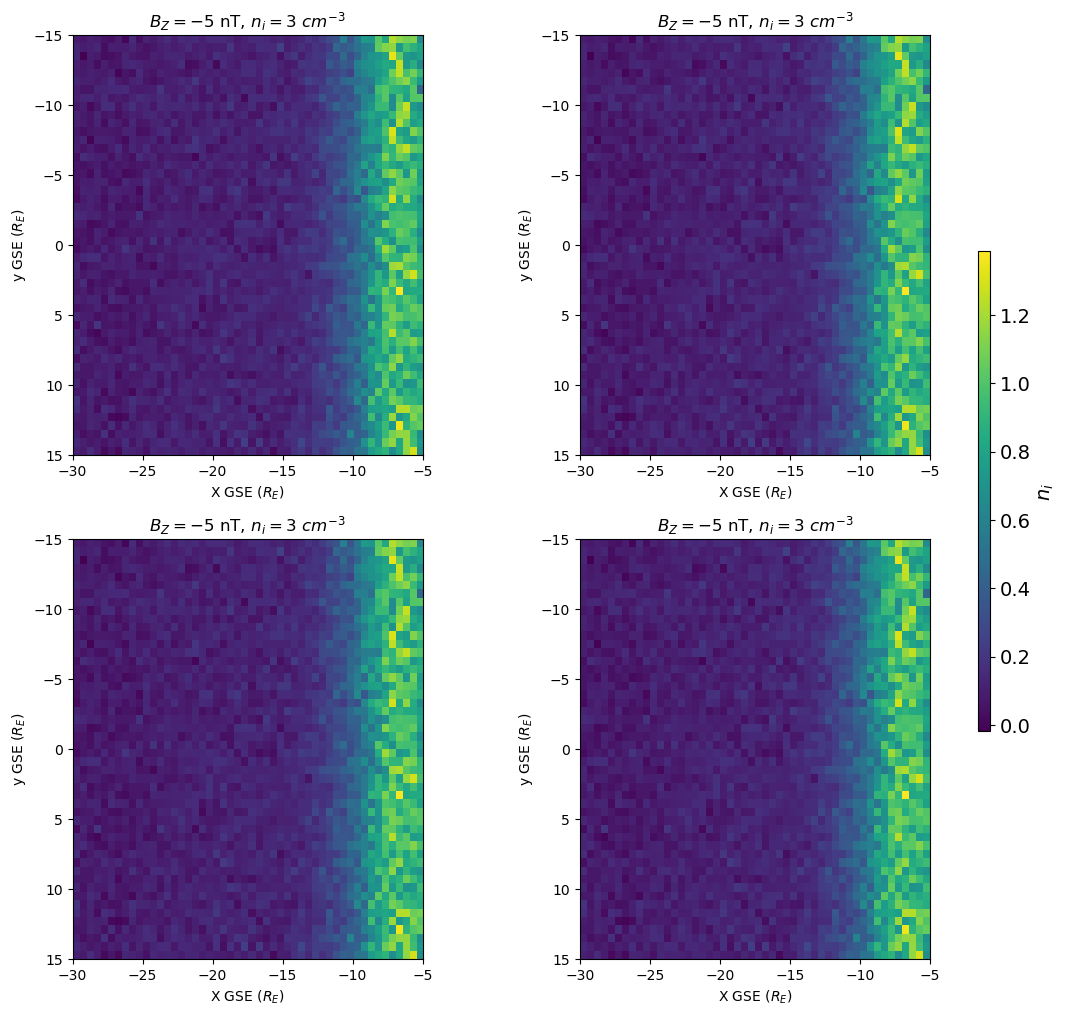

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (12, 12))
for idx, ax in enumerate(axes.flatten()):
    im = ax.imshow(output_grid[0,:,:,0], aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis')#, vmin = 0.1, vmax = 2)
    ax.set_xlabel(r'X GSE ($R_{E}$)')
    ax.set_ylabel(r'y GSE ($R_{E}$)')
    ax.set_title(r'$B_{Z}=' + str(synth_overrides['B_zgsm']) + r'$ nT, $n_{i}=' + str(synth_overrides['Ni']) + r'$ $cm^{-3}$')
cbar_ax = fig.add_axes([0.91, 0.3, 0.01, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$n_{i}$', fontsize=14)
cbar.ax.tick_params(labelsize=14)